In [8]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [9]:
load_dotenv()

True

In [10]:
# create llm
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [11]:
#lets create state
class BlogState(TypedDict):
    topic:str
    outline:str
    blog:str

In [12]:
#create node 
def gen_outline(state:BlogState)->BlogState:
    topic = state["topic"]
    prompt = f"generate a outline on the topic {topic}"
    outline = llm.invoke(prompt)
    state["outline"] = outline
    return state

In [13]:
def gen_blog(state:BlogState)->BlogState:
    outline = state["outline"]
    prompt = f"generate a blog on the outline {outline}"
    blog = llm.invoke(prompt)
    state["blog"] = blog
    return state

In [14]:
#create graph
graph = StateGraph(BlogState)

#add node
graph.add_node("gen_outline",gen_outline)

graph.add_node("gen_blog",gen_blog)

#add edges
graph.add_edge(START,"gen_outline")

graph.add_edge("gen_outline","gen_blog")

graph.add_edge("gen_blog",END)


In [15]:
#compile
workflow = graph.compile()

In [24]:
result = workflow.invoke({"topic":"Jama masjid"})

In [18]:
print(result["topic"])

Jama masjid


In [20]:
print((result["outline"]).content)

Here's an outline on the topic of Jama Masjid:

**Outline: Jama Masjid**

**I. Introduction**
    A. Full Name: Masjid-i Jahān-Numā (World-reflecting Mosque)
    B. Location: Old Delhi, India (Shahjahanabad)
    C. Builder: Mughal Emperor Shah Jahan
    D. Construction Period: 1644-1656 AD
    E. Significance: One of the largest and most renowned mosques in India, a prime example of Mughal architecture.

**II. Historical Context and Construction**
    A. Patronage: Emperor Shah Jahan (after building the Red Fort)
    B. Purpose:
        1. Imperial mosque for congregational prayers (Jummah).
        2. Symbol of Mughal power, piety, and architectural prowess.
        3. Central place of worship for the new city of Shahjahanabad.
    C. Architect: Ustad Khalil
    D. Cost and Labor: Immense resources, thousands of workers over 12 years.
    E. Inauguration: Imam Syed Abdul Ghafoor Shah Bukhari (first Imam).

**III. Architectural Features and Design**
    A. Style: Classic Mughal Archite

In [21]:
print(result["blog"].content)

## The Grandeur of Jama Masjid: A Timeless Jewel of Old Delhi

Step into the heart of Old Delhi, and you'll find yourself transported to an era of unparalleled imperial splendor. Towering above the bustling lanes and vibrant markets stands a monument that has witnessed centuries of history, devotion, and architectural brilliance: the **Jama Masjid**. More formally known as **Masjid-i Jahān-Numā**, or the "World-reflecting Mosque," it's not just a building; it's a living testament to Mughal grandeur and a spiritual beacon for millions.

### A Vision in Stone: Shah Jahan's Legacy

The story of Jama Masjid begins with one of India's most prolific builders, Mughal Emperor Shah Jahan. Having already gifted the world the iconic Red Fort, Shah Jahan embarked on another ambitious project: an imperial mosque befitting his new capital, Shahjahanabad (modern-day Old Delhi). From **1644 to 1656 AD**, over twelve years, immense resources and thousands of skilled workers toiled under the guidance of

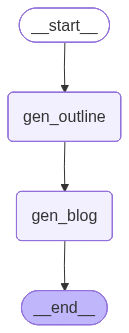

In [25]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))